<a href="https://colab.research.google.com/github/sdplamen/Decoding-F-Stop_Mathematical-concepts-in-Photography/blob/main/Decoding_the_F_Stop.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Decoding the f-stop (The Hidden Mathematics of Photography)

---

## Introduction

Every camera in the world shares the same mysterious sequence of numbers on its aperture dial:

$$f/1.4, \quad f/2, \quad f/2.8, \quad f/4, \quad f/5.6, \quad f/8, \quad f/11, \quad f/16$$

Most photographers memorize this sequence without ever asking: *why these numbers?* Why not f/1, f/2, f/3, f/4? Why does the sequence jump by seemingly irregular amounts?

The answer is pure mathematics — and it connects geometry, calculus, linear algebra, probability, and logic in one of the most elegant applied math stories in everyday life.

In this project we will:
- **Derive** the f-stop sequence from first principles using geometry
- **Model** the exposure triangle as a linear system in log-space
- **Optimize** exposure settings using calculus and gradient descent
- **Simulate** how cameras meter light using probability and statistics
- **Encode** photographer decision logic as a formal constraint system
- **Combine** everything into a Python Exposure Advisor

By the end, every time you turn a camera dial, you'll see the mathematics underneath.

## The f-stop Sequence: Where Does √2 Come From?

### 1.1 What is an f-stop?

The **f-number** (or f-stop) is defined as:

$$f\text{-number} = \frac{f}{D}$$

where $f$ is the **focal length** of the lens and $D$ is the **diameter of the aperture** (the opening that lets light in).

So f/2 means the aperture diameter is half the focal length. f/8 means the aperture is one-eighth the focal length — a much smaller opening.

Notice something immediately: **a larger f-number means a smaller aperture**. This is the first counterintuitive thing photographers learn.

### 1.2 Why $ \sqrt 2 $? The Geometry of Light

The amount of light reaching the sensor depends not on the diameter of the aperture, but on its **area**:

$$A = \pi \left(\frac{D}{2}\right)^2 = \frac{\pi D^2}{4}$$

Photographers define one **stop** as a factor of **2× in light** — either doubling or halving it. So the question becomes: by what factor must we multiply the diameter $D$ to double the area $A$?

$$2A = \frac{\pi (D \cdot x)^2}{4} \implies 2 = x^2 \implies x = \sqrt{2}$$

**Each stop requires multiplying the aperture diameter by $\sqrt{2} \approx 1.414$.**

Since $f\text{-number} = f/D$, and $D$ increases by $\sqrt{2}$ per stop, the f-number sequence is generated by **multiplying by $\sqrt{2}$ repeatedly** starting from f/1:

$$1, \; \sqrt{2}, \; 2, \; 2\sqrt{2}, \; 4, \; 4\sqrt{2}, \; 8, \ldots$$

Which rounds to: **1.0, 1.4, 2.0, 2.8, 4.0, 5.6, 8.0, 11, 16, 22...**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def generate_fstop_sequence(n_stops=12, start=1.0):
    return [start * (np.sqrt(2) ** i) for i in range(n_stops)]

fstops = generate_fstop_sequence(12)
standard = [1, 1.4, 2, 2.8, 4, 5.6, 8, 11, 16, 22, 32, 45]

print("f-stop sequence (derived):")
print("  " + "  ".join([f"f/{v:.2f}" for v in fstops]))
print("\nStandard camera markings:")
print("  " + "  ".join([f"f/{v}" for v in standard]))
print("\nDifference (rounding error):")
print("  " + "  ".join([f"{abs(a-b):.4f}" for a, b in zip(fstops, standard)]))

f-stop sequence (derived):
  f/1.00  f/1.41  f/2.00  f/2.83  f/4.00  f/5.66  f/8.00  f/11.31  f/16.00  f/22.63  f/32.00  f/45.25

Standard camera markings:
  f/1  f/1.4  f/2  f/2.8  f/4  f/5.6  f/8  f/11  f/16  f/22  f/32  f/45

Difference (rounding error):
  0.0000  0.0142  0.0000  0.0284  0.0000  0.0569  0.0000  0.3137  0.0000  0.6274  0.0000  0.2548


### 1.3 Half-Stops and Third-Stops

Modern cameras also offer **half-stop** and **third-stop** increments for finer control. These are generated by the same logic:

- **Half-stop**: multiply by $2^{1/4} = \sqrt{\sqrt{2}}$
- **Third-stop**: multiply by $2^{1/6}$

In [ ]:
def fstop_sequence(divisions_per_stop=1, n_stops=6, start=1.0):
    factor = 2 ** (1 / (2 * divisions_per_stop))
    n = n_stops * divisions_per_stop + 1
    return [round(start * factor ** i, 2) for i in range(n)]

full   = fstop_sequence(1)
half   = fstop_sequence(2)
third  = fstop_sequence(3)

print(f"Full stops  ({len(full)} values):  " + "  ".join([f"f/{v}" for v in full]))
print(f"Half stops  ({len(half)} values): " + "  ".join([f"f/{v}" for v in half]))
print(f"Third stops ({len(third)} values): " + "  ".join([f"f/{v}" for v in third]))

Full stops  (7 values):  f/1.0  f/1.41  f/2.0  f/2.83  f/4.0  f/5.66  f/8.0
Half stops  (13 values): f/1.0  f/1.19  f/1.41  f/1.68  f/2.0  f/2.38  f/2.83  f/3.36  f/4.0  f/4.76  f/5.66  f/6.73  f/8.0
Third stops (19 values): f/1.0  f/1.12  f/1.26  f/1.41  f/1.59  f/1.78  f/2.0  f/2.24  f/2.52  f/2.83  f/3.17  f/3.56  f/4.0  f/4.49  f/5.04  f/5.66  f/6.35  f/7.13  f/8.0


## Visualize aperture area vs f-stop

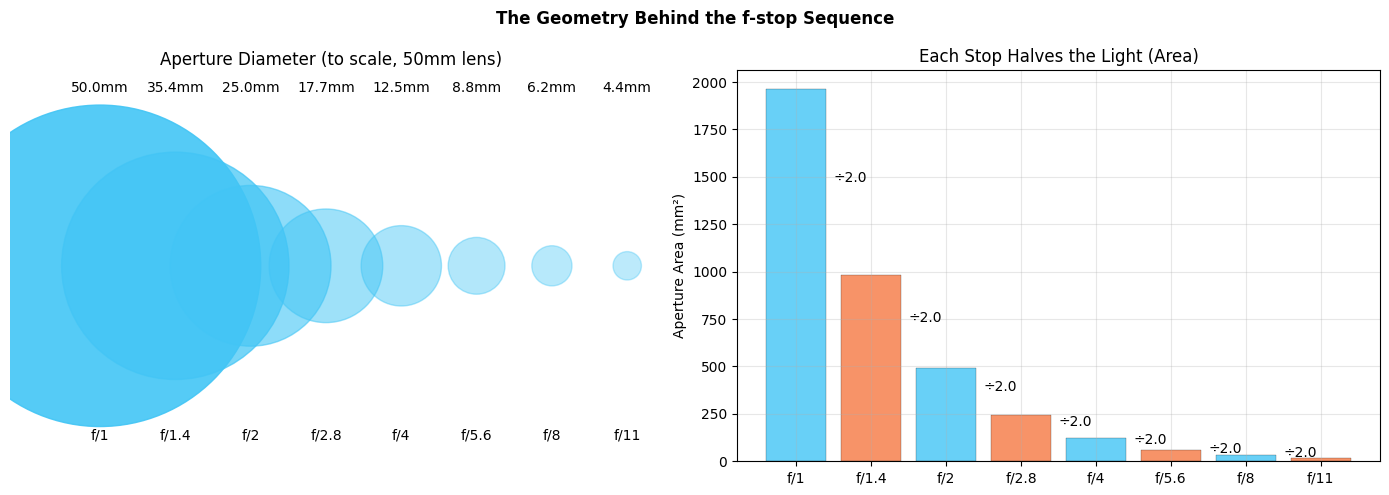


Area ratios between consecutive stops:
  f/1 → f/1.4: area ratio = 2.0000 (should be ~2.0)
  f/1.4 → f/2: area ratio = 2.0000 (should be ~2.0)
  f/2 → f/2.8: area ratio = 2.0000 (should be ~2.0)
  f/2.8 → f/4: area ratio = 2.0000 (should be ~2.0)
  f/4 → f/5.6: area ratio = 2.0000 (should be ~2.0)
  f/5.6 → f/8: area ratio = 2.0000 (should be ~2.0)
  f/8 → f/11: area ratio = 2.0000 (should be ~2.0)


In [ ]:
focal_length = 50
diameters = [focal_length / f for f in fstops[:8]]
areas = [np.pi * (d/2)**2 for d in diameters]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('The Geometry Behind the f-stop Sequence', fontweight='bold')

TEAL   = '#42c5f5'
CORAL  = '#f57842'

ax = axes[0]
ax.set_xlim(-1, 9)
ax.set_ylim(-3, 3)
ax.set_aspect('equal')
ax.set_title('Aperture Diameter (to scale, 50mm lens)')
ax.axis('off')

positions = np.linspace(0.4, 8.6, 8)
max_d = diameters[0]
for i, (pos, d, f) in enumerate(zip(positions, diameters, fstops[:8])):
    radius = (d / max_d) * 2.5
    alpha = 0.3 + 0.6 * (d / max_d)
    circle = plt.Circle((pos, 0), radius, color=TEAL, alpha=alpha)
    ax.add_patch(circle)
    ax.text(pos, -2.7, f'f/{standard[i]}', ha='center')
    ax.text(pos, 2.7, f'{d:.1f}mm', ha='center')

ax2 = axes[1]
bars = ax2.bar(range(8), areas, color=[TEAL if i % 2 == 0 else CORAL for i in range(8)], alpha=0.8, edgecolor='black', linewidth=0.2)
ax2.set_xticks(range(8))
ax2.set_xticklabels([f'f/{standard[i]}' for i in range(8)])
ax2.set_ylabel('Aperture Area (mm²)')
ax2.set_title('Each Stop Halves the Light (Area)')
ax2.grid(True, alpha=0.3)

for i in range(1, 8):
    ratio = areas[i-1] / areas[i]
    ax2.annotate(f'÷{ratio:.1f}', xy=(i-0.5, (areas[i-1]+areas[i])/2))

plt.tight_layout()
plt.show()

print("\nArea ratios between consecutive stops:")
for i in range(1, 8):
    print(f"  f/{standard[i-1]} → f/{standard[i]}: area ratio = {areas[i-1]/areas[i]:.4f} (should be ~2.0)")

## The Exposure Equation in Log-Space

### 1. The Exposure Triangle

A photograph's exposure depends on three variables:

| Variable | Symbol | Effect |
|---|---|---|
| Aperture (f-number) | $N$ | Controls depth of field & light |
| Shutter Speed | $t$ | Controls motion blur & light |
| Sensor Sensitivity | $S$ (ISO) | Controls noise & light |

The **Exposure Value (EV)** unifies all three into a single number:

$$EV = \log_2\left(\frac{N^2}{t}\right)$$

And when ISO is factored in, the **effective EV** at a given scene luminance $L$ is:

$$EV_{100} = \log_2\left(\frac{L \cdot S}{K}\right)$$

where $K \approx 12.5$ is the reflected-light meter calibration constant and $S$ is ISO.

### 2. Why Log-Space Makes Everything Linear

Taking $\log_2$ of the exposure equation:

$$EV = 2\log_2(N) - \log_2(t)$$

This is a **linear equation** in log-space! We can write the entire exposure triangle as:

$$EV = 2\log_2(N) - \log_2(t) - \log_2(S/100)$$

Let $a = \log_2(N)$, $b = \log_2(t)$, $c = \log_2(S/100)$. Then:

$$EV = 2a - b - c$$

In matrix form: $\mathbf{w}^T \mathbf{x} = EV$ where $\mathbf{w} = [2, -1, -1]$ and $\mathbf{x} = [a, b, c]^T$.

This means all valid exposure combinations for a given EV lie on a **hyperplane in log-space** — a fundamentally linear algebra insight.

### 3. The Sunny 16 Rule — A Linear Algebra Verification

Photographers use the famous **Sunny 16 Rule**: on a bright sunny day, set aperture to f/16 and shutter speed to 1/ISO.

Now is to verify this rule mathematically using our EV equation.